# Model A: NLP Transaction Classifier (TensorFlow.js Version)

**Arsitektur inferensi berlapis:**
1. **Rule-based keyword matching** - jika deskripsi mengandung kata kunci jelas (MCDONALD, PLN, NETFLIX), kategori langsung ditentukan
2. **Keras Sequential (char-ngram hashing + Dense softmax)** - untuk transaksi yang tidak cocok keyword
3. **Confidence threshold 0.70** - jika confidence < 0.70, fallback ke `lainnya`
4. **User re-labelling** - BAB 7 Buku Panduan

**Perubahan dari versi sebelumnya:**
- Model disimpan dalam format TensorFlow.js (`model.json` + `*.bin`) sehingga bisa di-load langsung di browser/frontend.
- TF-IDF + LinearSVC diganti dengan tokenizer char-ngram + Keras Sequential (Dense softmax).
- Konfigurasi tokenizer (vocabulary char-ngram → index) dan label encoder disimpan sebagai file `.json` terpisah agar bisa direkonstruksi di frontend.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, json, re
from collections import Counter
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)
tf.random.set_seed(42)
OUTPUT_DIR = "/content/drive/MyDrive/Capstone Projek/models"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Setup selesai. TF version:", tf.__version__)

Setup selesai. TF version: 2.20.0


In [3]:
# ─────────────────────────────────────────────────────────────────────────
# LOAD DATA
# ─────────────────────────────────────────────────────────────────────────
df = pd.read_csv("/content/dataset_a_nlp.csv")
print(f"Shape: {df.shape}")
print(f"\nDistribusi kategori:")
print(df["category"].value_counts().to_string())
print(f"\nContoh per kategori (transfer saja):")
for cat in ["transfer_keluarga","transfer_sosial","tidak_diketahui"]:
    s = df[df["category"]==cat]["description"].head(3).tolist()
    for ex in s:
        print(f"  [{cat}] {ex}")

Shape: (6300, 4)

Distribusi kategori:
category
makanan              800
belanja              700
tagihan              700
transport            600
kesehatan            600
pendidikan           600
hiburan              500
transfer_sosial      500
transfer_keluarga    500
lainnya              300
tidak_diketahui      200
topup_ewallet        200
transfer_internal    100

Contoh per kategori (transfer saja):
  [transfer_keluarga] TRF BULANAN KE TONO HARTONO
  [transfer_keluarga] E-BANKING DB 6669184950 KIRIMAN OKI PRATAMA
  [transfer_keluarga] TRF BULANAN KE DEWI LESTARI
  [transfer_sosial] PATUNGAN KADO DEWI LESTARI
  [transfer_sosial] PATUNGAN KADO SARI INDAH
  [transfer_sosial] TRF KE KARTINI SARI PATUNGAN WISATA
  [tidak_diketahui] TRF 139124 BNI
  [tidak_diketahui] TRSF DEBIT 60448444
  [tidak_diketahui] DB TRF 1201298371


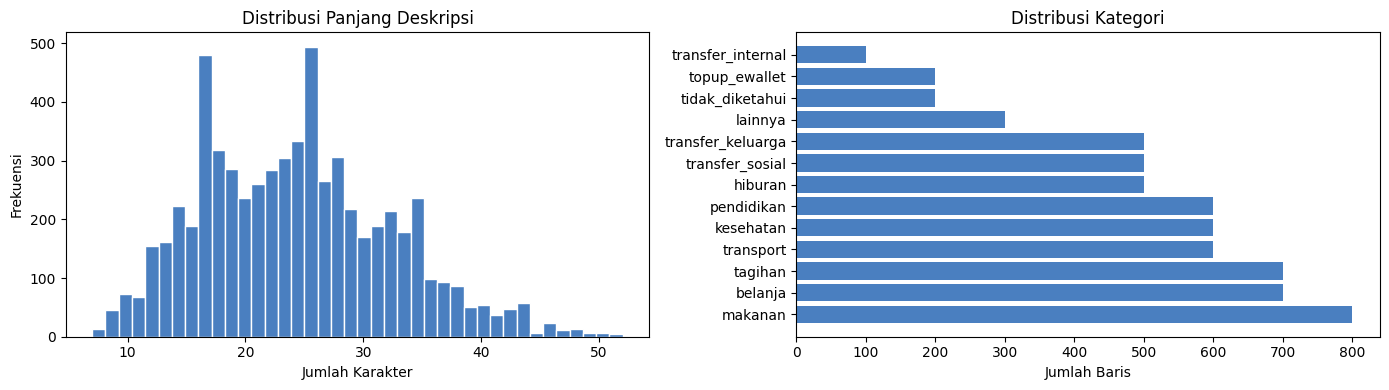

Avg panjang deskripsi: 24.3 karakter
Transaction type distribution:
transaction_type
debit       4800
transfer    1273
ewallet      227


In [4]:
# ─────────────────────────────────────────────────────────────────────────
# EDA — distribusi panjang deskripsi & channel
# ─────────────────────────────────────────────────────────────────────────
df["desc_len"] = df["description"].str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df["desc_len"], bins=40, color="#4A7FC0", edgecolor="white")
axes[0].set_title("Distribusi Panjang Deskripsi", fontsize=12)
axes[0].set_xlabel("Jumlah Karakter")
axes[0].set_ylabel("Frekuensi")

cat_counts = df["category"].value_counts()
axes[1].barh(cat_counts.index, cat_counts.values, color="#4A7FC0")
axes[1].set_title("Distribusi Kategori", fontsize=12)
axes[1].set_xlabel("Jumlah Baris")
plt.tight_layout()
# plt.savefig("/content/drive/MyDrive/Capstone Projek/datasets/eda_nlp_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Avg panjang deskripsi: {df['desc_len'].mean():.1f} karakter")
print(f"Transaction type distribution:")
print(df["transaction_type"].value_counts().to_string())

In [5]:
# ─────────────────────────────────────────────────────────────────────────
# LAYER 1: RULE-BASED KEYWORD MATCHER
# ─────────────────────────────────────────────────────────────────────────

KEYWORD_RULES = {
    "makanan": [
        "MCDONALD", "KFC", "BURGER KING", "PIZZA HUT", "HOKBEN", "YOSHINOYA",
        "J.CO", "JCO", "STARBUCKS", "KOPI KENANGAN", "FORE COFFEE", "JANJI JIWA",
        "ES TEH", "MIXUE", "CHATIME", "GULU GULU", "SOLARIA", "BAKMI GM",
        "SUSHI TEI", "MARUGAME", "PEPPER LUNCH", "WARTEG", "WARUNG PADANG",
        "BAKSO", "AYAM GEPREK", "SABANA FRIED CHICKEN", "RICHEESE",
        "WINGSTOP", "DOMINO", "PHD", "A&W", "HOKA HOKA",
        "GRABFOOD", "GOFOOD", "SHOPEEFOOD",
    ],
    "transport": [
        "PERTAMINA", "SHELL SPBU", "VIVO SPBU", "BP SPBU",
        "KRL COMMUTERLINE", "MRT JAKARTA", "LRT JABODEBEK", "TRANSJAKARTA",
        "BLUE BIRD TAXI", "GRAB RIDE", "GOJEK RIDE", "MAXIM",
        "TRAVELOKA", "KAI ACCESS", "TIKET.COM",
        "FLAZZ", "E-TOLL", "TOL ", "PARKIR",
    ],
    "tagihan": [
        "PLN TOKEN", "PLN PASCABAYAR", "PLN PREPAID",
        "TELKOMSEL", "INDOSAT", "XL AXIATA", "SMARTFREN", "TRI HUTCHISON",
        "INDIHOME", "BIZNET", "FIRSTMEDIA", "MYREPUBLIC",
        "BPJS KESEHATAN", "BPJS KETENAGAKERJAAN",
        "PDAM", "PGN GAS",
        "CICILAN KPR", "CICILAN KENDARAAN", "ADIRA FINANCE", "FIF MOTOR",
        "IURAN IPL", "IURAN BULANAN RT",
    ],
    "hiburan": [
        "NETFLIX", "SPOTIFY", "DISNEY+", "DISNEY PLUS", "VIDIO",
        "YOUTUBE PREMIUM", "APPLE MUSIC", "HBO",
        "STEAM", "GOOGLE PLAY GAMES", "APPLE STORE",
        "CODASHOP", "UNIPIN", "GARENA", "MOBILE LEGENDS",
        "TIKTOK COINS",
        "BIOSKOP XXI", "BIOSKOP CGV", "CINEPOLIS",
        "TIMEZONE", "GYM", "FITNESS", "KARAOKE",
    ],
    "belanja": [
        "INDOMARET", "ALFAMART", "ALFAMIDI", "LAWSON",
        "UNIQLO", "H&M", "ZARA", "COTTON INK", "ERIGO",
        "MINISO", "DAISO", "ACE HARDWARE",
        "TRANSMART", "HYPERMART", "SUPERINDO", "RANCH MARKET",
        "GUARDIAN", "WATSONS", "SOCIOLLA", "BODY SHOP",
        "ERAFONE", "IBOX", "SAMSUNG STORE",
        "SHOPEE", "TOKOPEDIA", "LAZADA", "BLIBLI", "TIKTOK SHOP",
    ],
    "kesehatan": [
        "APOTEK K24", "KIMIA FARMA", "APOTEK CENTURY", "APOTEK VIVA",
        "RS SILOAM", "RS HERMINA", "RS MITRA KELUARGA", "RS PREMIER",
        "KLINIK", "LABORATORIUM PRODIA", "OPTIK MELAWAI", "OPTIK SEIS",
        "HALODOC", "ALODOKTER", "KLIKDOKTER", "GOOD DOCTOR",
    ],
    "pendidikan": [
        "SPP UNIVERSITAS", "UKT SEMESTER", "BIAYA KULIAH",
        "BIMBEL GANESHA", "BIMBEL PRIMAGAMA", "NEUTRON",
        "EF ENGLISH", "KURSUS LIA",
        "GRAMEDIA", "PERIPLUS", "TOGA MAS",
        "RUANGGURU", "ZENIUS", "COURSERA", "UDEMY",
        "SKILL ACADEMY", "DUOLINGO", "LINKEDIN LEARNING",
    ],
    "topup_ewallet": [
        "TOP UP GOPAY", "TOP UP OVO", "TOP UP DANA", "TOP UP SHOPEEPAY",
        "TOPUP SHOPEEPAY", "TOPUP OVO", "TOP UP LINKAJA",
        "TRANSFER KE GOPAY", "TRF KE DANA",
        "PEMBELIAN E-MONEY",
    ],
    "transfer_internal": [
        "REK SENDIRI", "OVERBOOKING", "SA OB CA TABUNGAN",
        "PBK GIRO KE TABUNGAN", "PBK KE TABUNGAN",
        "TABUNGAN BISNIS",
    ],
    "transfer_keluarga": [
        "NAFKAH", "KIRIMAN KELUARGA", "TRF BULANAN", "TRF RUTIN BULANAN",
        "TRANSFER KE", "TRF ORANG TUA", "KIRIM NAFKAH",
    ],
    "transfer_sosial": [
        "ARISAN", "IURAN ARISAN", "PATUNGAN", "KONDANGAN",
        "DONASI PMI", "SUMBANGAN", "TRF PATUNGAN",
    ],
}

def rule_based_classify(desc):
    """Layer 1: keyword matching. Return (category, True) jika cocok."""
    desc_up = desc.upper()
    for cat, keywords in KEYWORD_RULES.items():
        for kw in keywords:
            if kw in desc_up:
                return cat, True
    return None, False

# Test layer 1
test_descs = [
    "DEBIT EDC MCDONALD'S JKT",
    "IPY PLN TOKEN LISTRIK 12345678",
    "PYMNT NETFLIX.COM",
    "TRSF E-BANKING DB 0812345678",
    "TRF ARISAN DEWI LESTARI",
    "TRF BULANAN KE AHMAD FAUZI",
]
print("Test Rule-Based Layer 1:")
for d in test_descs:
    cat, matched = rule_based_classify(d)
    print(f"  '{d}' → {cat} (matched={matched})")

Test Rule-Based Layer 1:
  'DEBIT EDC MCDONALD'S JKT' → makanan (matched=True)
  'IPY PLN TOKEN LISTRIK 12345678' → tagihan (matched=True)
  'PYMNT NETFLIX.COM' → hiburan (matched=True)
  'TRSF E-BANKING DB 0812345678' → None (matched=False)
  'TRF ARISAN DEWI LESTARI' → transfer_sosial (matched=True)
  'TRF BULANAN KE AHMAD FAUZI' → transfer_keluarga (matched=True)


In [6]:
# ─────────────────────────────────────────────────────────────────────────
# TRAIN / TEST SPLIT — stratified berdasarkan kategori
# ─────────────────────────────────────────────────────────────────────────

df["rule_pred"], df["rule_matched"] = zip(*df["description"].map(rule_based_classify))

df_rule_matched = df[df["rule_matched"] == True].copy()
df_nlp_needed   = df[df["rule_matched"] == False].copy()

print(f"Rule-matched (tidak perlu model NLP): {len(df_rule_matched):,} baris")
print(f"Perlu model NLP:                      {len(df_nlp_needed):,} baris")

rule_acc = (df_rule_matched["rule_pred"] == df_rule_matched["category"]).mean()
print(f"\nAkurasi layer 1 (rule-based): {rule_acc:.2%}")

X_nlp = df_nlp_needed["description"]
y_nlp = df_nlp_needed["category"]

X_train, X_test, y_train, y_test = train_test_split(
    X_nlp, y_nlp, test_size=0.20, random_state=42, stratify=y_nlp
)
print(f"\nDataset NLP layer train: {len(X_train):,} | test: {len(X_test):,}")
print("Distribusi kelas di test set:")
print(y_test.value_counts().to_string())

Rule-matched (tidak perlu model NLP): 3,898 baris
Perlu model NLP:                      2,402 baris

Akurasi layer 1 (rule-based): 94.66%

Dataset NLP layer train: 1,921 | test: 481
Distribusi kelas di test set:
category
transfer_keluarga    69
lainnya              52
belanja              52
pendidikan           46
transfer_sosial      43
tidak_diketahui      40
tagihan              38
kesehatan            38
makanan              29
hiburan              29
transport            28
topup_ewallet        12
transfer_internal     5


In [7]:
# ─────────────────────────────────────────────────────────────────────────
# CHAR N-GRAM TOKENIZER (pengganti TfidfVectorizer)
# Vocabulary disimpan sebagai .json agar bisa direkonstruksi di TF.js
# ─────────────────────────────────────────────────────────────────────────

NGRAM_MIN = 2
NGRAM_MAX = 5
MAX_VOCAB = 30_000

def _normalize(text):
    """Lowercase + collapse whitespace + pad untuk char_wb-style."""
    t = text.lower().strip()
    t = re.sub(r"\s+", " ", t)
    return " " + t + " "

def _char_ngrams(text, nmin=NGRAM_MIN, nmax=NGRAM_MAX):
    """Char-window n-grams (mirip TfidfVectorizer analyzer='char_wb')."""
    t = _normalize(text)
    grams = []
    for n in range(nmin, nmax + 1):
        if len(t) < n:
            continue
        for i in range(len(t) - n + 1):
            grams.append(t[i:i+n])
    return grams

def build_vocab(texts, max_vocab=MAX_VOCAB):
    """Bangun mapping ngram -> index berdasarkan frekuensi (top-K)."""
    counter = Counter()
    for t in texts:
        counter.update(_char_ngrams(t))
    most_common = counter.most_common(max_vocab)
    # Index 0 = padding/OOV, index 1.. = token
    vocab = {tok: i + 1 for i, (tok, _) in enumerate(most_common)}
    return vocab

def vectorize(text, vocab):
    """Sub-linear TF vector berukuran len(vocab)+1 (bag-of-ngrams)."""
    vec = np.zeros(len(vocab) + 1, dtype=np.float32)
    for g in _char_ngrams(text):
        idx = vocab.get(g)
        if idx is not None:
            vec[idx] += 1.0
    # sublinear tf: 1 + log(tf)
    nz = vec > 0
    vec[nz] = 1.0 + np.log(vec[nz])
    # L2 normalize
    norm = np.linalg.norm(vec)
    if norm > 0:
        vec /= norm
    return vec

def vectorize_batch(texts, vocab):
    return np.stack([vectorize(t, vocab) for t in texts], axis=0)

print("Membangun vocabulary dari X_train...")
vocab = build_vocab(X_train.tolist(), max_vocab=MAX_VOCAB)
INPUT_DIM = len(vocab) + 1
print(f"Vocab size (termasuk OOV slot): {INPUT_DIM:,}")

# Label encoder (string -> int)
classes_ = sorted(y_nlp.unique().tolist())
label2idx = {c: i for i, c in enumerate(classes_)}
idx2label = {i: c for c, i in label2idx.items()}
NUM_CLASSES = len(classes_)
print(f"Num classes: {NUM_CLASSES} → {classes_}")

Membangun vocabulary dari X_train...
Vocab size (termasuk OOV slot): 22,454
Num classes: 13 → ['belanja', 'hiburan', 'kesehatan', 'lainnya', 'makanan', 'pendidikan', 'tagihan', 'tidak_diketahui', 'topup_ewallet', 'transfer_internal', 'transfer_keluarga', 'transfer_sosial', 'transport']


In [ ]:
# ─────────────────────────────────────────────────────────────────────────
# LAYER 2: KERAS SEQUENTIAL (pengganti LinearSVC + Calibration)
# Char-ngram BoW vector → Dense(softmax) ≈ multinomial logistic regression
# yang memberikan probabilitas terkalibrasi out-of-the-box.
# ─────────────────────────────────────────────────────────────────────────

# Hitung class weights (mengganti class_weight='balanced' di LinearSVC)
from sklearn.utils.class_weight import compute_class_weight
cw = compute_class_weight("balanced", classes=np.array(classes_), y=y_train.values)
class_weight = {i: float(w) for i, w in enumerate(cw)}

# Vectorize
print("Vectorizing train/test...")
X_train_vec = vectorize_batch(X_train.tolist(), vocab)
X_test_vec  = vectorize_batch(X_test.tolist(),  vocab)
y_train_idx = y_train.map(label2idx).values.astype(np.int32)
y_test_idx  = y_test.map(label2idx).values.astype(np.int32)
print(f"X_train_vec: {X_train_vec.shape} | X_test_vec: {X_test_vec.shape}")

def build_model(input_dim, num_classes):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,), name="ngram_vector"),
        layers.Dense(128, activation="relu", kernel_regularizer=keras.regularizers.l2(1e-4)),
        layers.Dropout(0.3),
        layers.Dense(64, activation="relu", kernel_regularizer=keras.regularizers.l2(1e-4)),
        layers.Dropout(0.2),
        layers.Dense(num_classes, activation="softmax", name="category_probs"),
    ], name="nlp_transaction_classifier")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

pipeline = build_model(INPUT_DIM, NUM_CLASSES)
pipeline.summary()

print("\nTraining Keras Sequential...")
early = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=4, restore_best_weights=True
)
history = pipeline.fit(
    X_train_vec, y_train_idx,
    validation_split=0.15,
    epochs=40,
    batch_size=64,
    class_weight=class_weight,
    callbacks=[early],
    verbose=2,
)
print("Training selesai.")

# 5-fold CV F1-macro (sama seperti notebook lama)
print("\nMenjalankan 5-Fold CV (F1-macro)...")
X_all_vec = vectorize_batch(X_nlp.tolist(), vocab)
y_all_idx = y_nlp.map(label2idx).values.astype(np.int32)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []
for fold, (tr_idx, va_idx) in enumerate(skf.split(X_all_vec, y_all_idx), 1):
    m = build_model(INPUT_DIM, NUM_CLASSES)
    m.fit(X_all_vec[tr_idx], y_all_idx[tr_idx],
          epochs=15, batch_size=64, verbose=0,
          class_weight=class_weight)
    proba = m.predict(X_all_vec[va_idx], verbose=0)
    pred  = proba.argmax(axis=1)
    score = f1_score(y_all_idx[va_idx], pred, average="macro")
    cv_scores.append(score)
    print(f"  Fold {fold}: F1-macro = {score:.4f}")
cv_scores = np.array(cv_scores)
print(f"\n5-Fold CV F1-macro: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Vectorizing train/test...
X_train_vec: (1921, 22454) | X_test_vec: (481, 22454)


Model: "nlp_transaction_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │     2,874,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ category_probs (Dense)          │ (None, 13)             │           845 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,883,341 (11.00 MB)

 Trainable params: 2,883,341 (11.00 MB)

 Non-trainable params: 0 (0.00 B)


Training Keras Sequential...
Epoch 1/40
26/26 - 3s - 131ms/step - accuracy: 0.4504 - loss: 2.4736 - val_accuracy: 0.7647 - val_loss: 2.1801
Epoch 2/40
26/26 - 3s - 111ms/step - accuracy: 0.8248 - loss: 1.7865 - val_accuracy: 0.9377 - val_loss: 1.2558
Epoch 3/40
26/26 - 4s - 170ms/step - accuracy: 0.9338 - loss: 0.8703 - val_accuracy: 0.9619 - val_loss: 0.5569
Epoch 4/40
26/26 - 3s - 100ms/step - accuracy: 0.9743 - loss: 0.4031 - val_accuracy: 0.9550 - val_loss: 0.3248
Epoch 5/40
26/26 - 2s - 81ms/step - accuracy: 0.9859 - loss: 0.2383 - val_accuracy: 0.9585 - val_loss: 0.2594
Epoch 6/40
26/26 - 1s - 56ms/step - accuracy: 0.9908 - loss: 0.1920 - val_accuracy: 0.9689 - val_loss: 0.2278
Epoch 7/40
26/26 - 3s - 101ms/step - accuracy: 0.9939 - loss: 0.1661 - val_accuracy: 0.9619 - val_loss: 0.2240
Epoch 8/40
26/26 - 3s - 115ms/step - accuracy: 0.9945 - loss: 0.1510 - val_accuracy: 0.9550 - val_loss: 0.2141
Epoch 9/40
26/26 - 2s - 77ms/step - accuracy: 0.9939 - loss: 0.1418 - val_accuracy: 

In [ ]:
# ─────────────────────────────────────────────────────────────────────────
# EVALUASI LAYER 2 (NLP)
# ─────────────────────────────────────────────────────────────────────────

y_proba   = pipeline.predict(X_test_vec, verbose=0)
y_pred_id = y_proba.argmax(axis=1)
y_pred    = np.array([idx2label[i] for i in y_pred_id])
max_conf  = y_proba.max(axis=1)

CONFIDENCE_THRESHOLD = 0.70
y_pred_final = np.where(max_conf >= CONFIDENCE_THRESHOLD, y_pred, "lainnya")

acc_before = accuracy_score(y_test, y_pred)
acc_after  = accuracy_score(y_test, y_pred_final)
f1_before  = f1_score(y_test, y_pred, average="macro")
f1_after   = f1_score(y_test, y_pred_final, average="macro")
low_conf   = (max_conf < CONFIDENCE_THRESHOLD).sum()

print(f"Akurasi NLP tanpa threshold: {acc_before:.4f}")
print(f"Akurasi NLP dengan threshold {CONFIDENCE_THRESHOLD}: {acc_after:.4f}")
print(f"F1-macro tanpa threshold:    {f1_before:.4f}")
print(f"F1-macro dengan threshold:   {f1_after:.4f}")
print(f"Prediksi fallback ke lainnya: {low_conf:,} ({low_conf/len(y_test):.1%})")
print("\nClassification Report (dengan threshold):")
print(classification_report(y_test, y_pred_final))

Akurasi NLP tanpa threshold: 0.9709
Akurasi NLP dengan threshold 0.7: 0.9397
F1-macro tanpa threshold:    0.9742
F1-macro dengan threshold:   0.9455
Prediksi fallback ke lainnya: 23 (4.8%)

Classification Report (dengan threshold):
                   precision    recall  f1-score   support

          belanja       1.00      0.98      0.99        52
          hiburan       1.00      1.00      1.00        29
        kesehatan       1.00      0.97      0.99        38
          lainnya       0.69      1.00      0.82        52
          makanan       0.93      0.97      0.95        29
       pendidikan       1.00      0.93      0.97        46
          tagihan       1.00      0.97      0.99        38
  tidak_diketahui       0.95      0.93      0.94        40
    topup_ewallet       1.00      1.00      1.00        12
transfer_internal       1.00      0.80      0.89         5
transfer_keluarga       0.98      0.91      0.95        69
  transfer_sosial       0.97      0.77      0.86        43


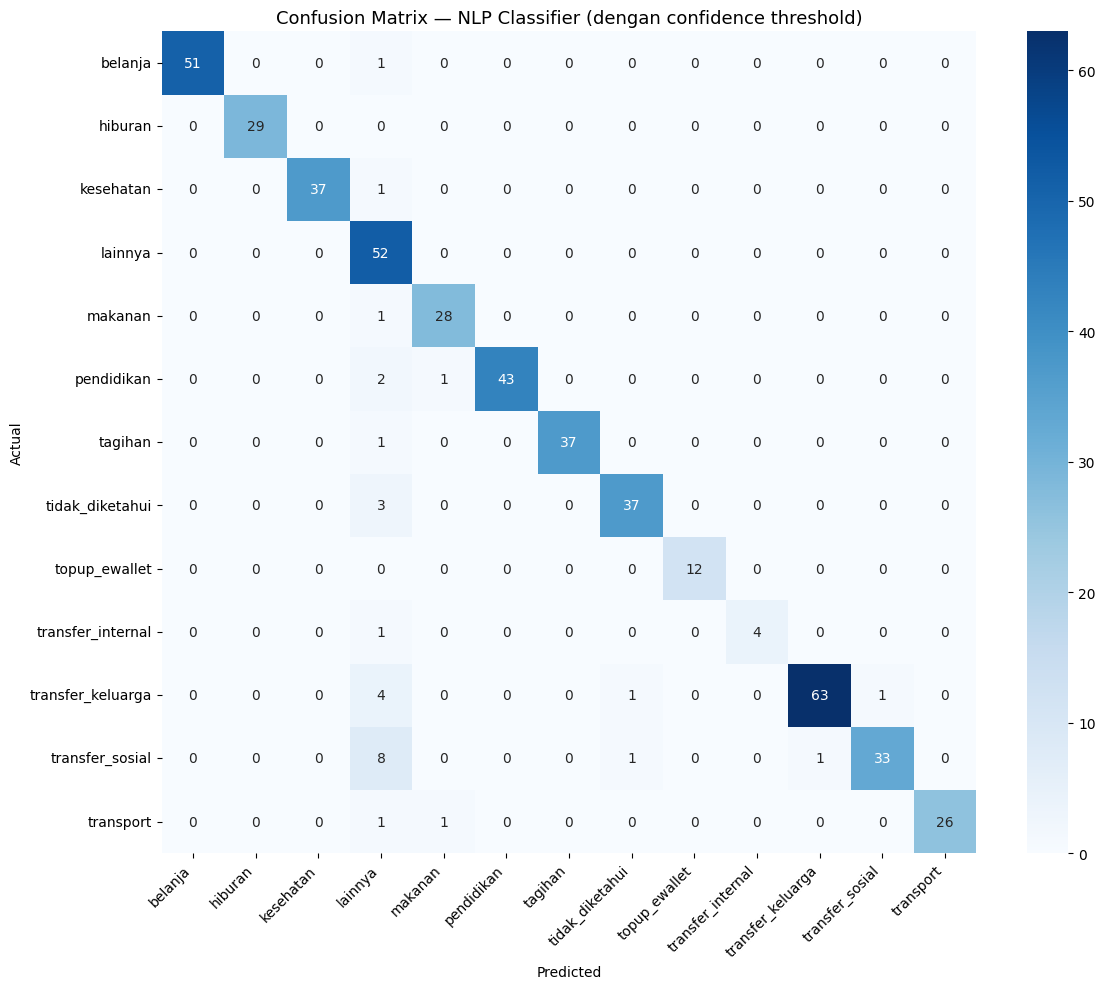

Confusion matrix disimpan.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────
# CONFUSION MATRIX
# ─────────────────────────────────────────────────────────────────────────

labels = sorted(y_test.unique())
cm     = confusion_matrix(y_test, y_pred_final, labels=labels)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix — NLP Classifier (dengan confidence threshold)", fontsize=13)
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
# plt.savefig("datasets/cm_nlp_model_a.png", dpi=150, bbox_inches="tight")
plt.show()
print("Confusion matrix disimpan.")

In [ ]:
# ─────────────────────────────────────────────────────────────────────────
# EVALUASI END-TO-END (Layer 1 + Layer 2 + Fallback)
# ─────────────────────────────────────────────────────────────────────────

all_true, all_pred_final = [], []

# Batch vectorize untuk efisiensi (logika identik dengan loop per-baris)
needs_nlp_mask = ~df["rule_matched"].values
nlp_desc       = df.loc[needs_nlp_mask, "description"].tolist()
if len(nlp_desc) > 0:
    nlp_vec   = vectorize_batch(nlp_desc, vocab)
    nlp_proba = pipeline.predict(nlp_vec, verbose=0)
else:
    nlp_proba = np.zeros((0, NUM_CLASSES))

nlp_iter = iter(nlp_proba)
for _, row in df.iterrows():
    cat_rule, matched = rule_based_classify(row["description"])
    if matched:
        pred_final = cat_rule
    else:
        proba = next(nlp_iter)
        conf  = float(proba.max())
        pred  = idx2label[int(proba.argmax())]
        pred_final = pred if conf >= CONFIDENCE_THRESHOLD else "lainnya"
    all_true.append(row["category"])
    all_pred_final.append(pred_final)

e2e_acc = accuracy_score(all_true, all_pred_final)
e2e_f1  = f1_score(all_true, all_pred_final, average="macro")
print(f"Akurasi End-to-End (Layer 1+2+Fallback): {e2e_acc:.4f}")
print(f"F1-macro End-to-End:                     {e2e_f1:.4f}")

Akurasi End-to-End (Layer 1+2+Fallback): 0.9589
F1-macro End-to-End:                     0.9576


In [ ]:
# ─────────────────────────────────────────────────────────────────────────
# EKSPOR MODEL (.keras) & METADATA
# ─────────────────────────────────────────────────────────────────────────
import os
import json
import joblib

print("\nMenyimpan model ke format .keras...")
model_dir = os.path.join(OUTPUT_DIR, "nlp_model")
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

# 1. Simpan model Keras dengan ekstensi .keras
keras_model_path = os.path.join(model_dir, "model.keras")
pipeline.save(keras_model_path)
print(f"Model berhasil disimpan di: {keras_model_path}")

# 2. Simpan metadata (vocabulary, label encoder, threshold)
metadata = {
    "vocab": vocab,
    "idx2label": idx2label,
    "confidence_threshold": 0.70
}
metadata_path = os.path.join(model_dir, "metadata.json")
with open(metadata_path, "w") as f:
    json.dump(metadata, f)
print(f"Metadata berhasil disimpan di: {metadata_path}")

# 3. (Opsional) Simpan variabel vocab menggunakan joblib jika diwajibkan
joblib_path = os.path.join(model_dir, "vectorizer.pkl")
joblib.dump(vocab, joblib_path)  # Menyimpan kamus vocab sebagai 'vectorizer'
print(f"Vectorizer (vocab) berhasil diekspor menggunakan joblib di: {joblib_path}")


Menyimpan model ke format .keras...
Model berhasil disimpan di: /content/drive/MyDrive/Capstone Projek/models/nlp_model/model.keras
Metadata berhasil disimpan di: /content/drive/MyDrive/Capstone Projek/models/nlp_model/metadata.json
Vectorizer (vocab) berhasil diekspor menggunakan joblib di: /content/drive/MyDrive/Capstone Projek/models/nlp_model/vectorizer.pkl
